# Exploring SOMISANA Operational Ocean Forecasts

**A tutorial in operational oceanography**

This notebook is a hands-on introduction to the ocean forecast products produced
by **SOMISANA** — the *Sustainable Ocean Modelling Initiative: a South African
Approach* (https://somisana.ac.za/). SOMISANA runs the [CROCO](https://www.croco-ocean.org/)
regional ocean model operationally around South Africa and publishes the output
through a THREDDS/ERDDAP catalog: https://catalog.somisana.ac.za/catalog/

For this exersice you will download **daily forecast files** for **two regions** and **four
model configurations**:

| | GFS atmospheric forcing | SAWS atmospheric forcing |
|---|---|---|
| **HYCOM** boundary/initial conditions | `HYCOM-GFS` | `HYCOM-SAWS` |
| **MERCATOR** boundary/initial conditions | `MERCATOR-GFS` | `MERCATOR-SAWS` |

for the regions:

- **SA-West** — the Benguela / Cape Town shelf region
- **SA-East** — a smaller domain around Cape Point / False Bay

That is, CROCO (the regional model) is **nested** inside one of two global ocean
models (**HYCOM** or **Mercator**, which supply the open-boundary and initial
conditions), and is forced at the surface by one of two atmospheric products
(**GFS**, the NOAA/NCEP global forecast, or **SAWS**, the South African Weather
Service regional forecast). Tides are added from **TPXO10**. Comparing the four
combinations is a simple way to explore *forecast uncertainty that comes from
the choice of forcing data*, which is one of the central themes of operational
oceanography.

Each configuration folder on the server contains two files:

- `croco_avg_t3.nc` — the original **hourly** model output, regridded onto a
  regular lon/lat/depth grid (CROCO's native grid is a curvilinear sigma-coordinate
  grid; `t3` = "tier 3" in SOMISANA's processing chain, meaning it has been
  interpolated onto fixed z-levels and a regular horizontal grid, which makes it
  much easier to work with).
- `croco_avg_t3_day.nc` — the same fields **averaged to daily means** (created
  here with `cdo dayavg`, see the file's `history` attribute). This is the file
  you will want for most exploratory work, since it's ~20x smaller and daily
  averages are usually what's needed for a forecast overview.

To keep the download small, this notebook only fetches the **daily-mean**
files (`croco_avg_t3_day.nc`, ~500 MB in total across both regions and all
four configurations) — the raw hourly files are many times larger and aren't
needed for anything we do here.

### Learning objectives

By the end of this notebook you will be able to:

1. Open and interpret the structure of a SOMISANA forecast file (dimensions,
   coordinates, variables, metadata).
2. Understand *why* and *how* daily averages differ from the native hourly
   output.
3. Make publication-style maps of sea-surface and bottom fields with `cartopy`.
4. Compare the four nesting/forcing configurations against each other, to
   separate the effect of the **ocean boundary conditions** from the effect of
   the **atmospheric forcing**.
5. Look at the vertical structure of the water column and how it evolves over
   the forecast period.
6. Compute a simple derived product (surface current speed) from the model
   output.


## 1. Setup

In [1]:
# Run once per environment (e.g. once per Colab session, or once in your local conda/venv)
%pip install -q numpy xarray matplotlib cartopy netCDF4 pathlib


Note: you may need to restart the kernel to use updated packages.


In [2]:

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


In [3]:
# The forecast files live on the SOMISANA sigma2 server, mirrored under the
# same folder layout we use locally: <region>/<config>/croco_avg_t3_day.nc
BASE_URL = "https://ns9481k.web.sigma2.no/SOMISANA_forecasts"

# We'll download into a "SOMISANA_forecasts" folder created next to this notebook.
BASE_DIR = Path("SOMISANA_forecasts").resolve()

REGIONS = ["SA-West", "SA-East"]
CONFIGS = ["HYCOM-GFS", "MERCATOR-GFS", "HYCOM-SAWS", "MERCATOR-SAWS"]

def filepath(region, config):
    '''Return the local path to a SOMISANA daily-mean forecast file.'''
    return BASE_DIR / region / config / "croco_avg_t3_day.nc"

def remote_url(region, config):
    '''Return the URL of a SOMISANA daily-mean forecast file on the sigma2 server.'''
    return f"{BASE_URL}/{region}/{config}/croco_avg_t3_day.nc"


### Downloading the data

The daily-mean forecast files (`croco_avg_t3_day.nc`) for both regions and all
four configurations are hosted at
https://ns9481k.web.sigma2.no/SOMISANA_forecasts/, using the same
`<region>/<config>/` layout as `filepath()` above. The cell below uses
`wget` to fetch each one into `BASE_DIR`, skipping any file that's already
been downloaded (so re-running the cell is cheap and safe to interrupt/resume
across sessions). This is **~500 MB in total**.

**Note**: this requires `wget` to be installed and on your `PATH` (already
the case on Colab/most Linux systems; on macOS install it with
`brew install wget`).


In [5]:
import subprocess

def download_file(region, config):
    '''Download one SOMISANA daily-mean forecast file with wget, unless it's already on disk.'''
    dest = filepath(region, config)
    if dest.exists():
        print(f"{dest.relative_to(BASE_DIR)}  already downloaded, skipping")
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    url = remote_url(region, config)
    print(f"Downloading {url}\n  -> {dest}")
    subprocess.run(
        ["wget", "-q", "--show-progress", "-O", str(dest), url],
        check=True,
    )

# Fetch the daily-mean file for every region/configuration combination.
for region in REGIONS:
    for config in CONFIGS:
        download_file(region, config)


  -> /Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/HYCOM-GFS/croco_avg_t3_day.nc



     0K .......... .......... .......... .......... ..........  0%  944K 2m12s
    50K .......... .......... .......... .......... ..........  0% 1.94M 97s
   100K .......... .......... .......... .......... ..........  0% 83.3M 65s
   150K .......... .......... .......... .......... ..........  0% 78.1M 49s
   200K .......... .......... .......... .......... ..........  0% 1.89M 52s
   250K .......... .......... .......... .......... ..........  0% 75.5M 44s
   300K .......... .......... .......... .......... ..........  0% 69.6M 38s
   350K .......... .......... .......... .......... ..........  0% 80.2M 33s
   400K .......... .......... .......... .......... ..........  0% 1.98M 36s
   450K .......... .......... .......... .......... ..........  0% 65.5M 33s
   500K .......... .......... .......... .......... ..........  0% 88.5M 30s
   550K .......... .......... .......... .......... ..........  0%  892K 39s
   600K .......... .......... .......... .......... ..........  0%  142M 

  -> /Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/MERCATOR-GFS/croco_avg_t3_day.nc



     0K .......... .......... .......... .......... ..........  0%  977K 2m8s
    50K .......... .......... .......... .......... ..........  0% 1.99M 94s
   100K .......... .......... .......... .......... ..........  0% 27.8M 64s
   150K .......... .......... .......... .......... ..........  0% 98.4M 48s
   200K .......... .......... .......... .......... ..........  0% 2.02M 51s
   250K .......... .......... .......... .......... ..........  0% 30.5M 43s
   300K .......... .......... .......... .......... ..........  0%  126M 37s
   350K .......... .......... .......... .......... ..........  0% 42.5M 33s
   400K .......... .......... .......... .......... ..........  0% 2.06M 36s
   450K .......... .......... .......... .......... ..........  0% 63.9M 32s
   500K .......... .......... .......... .......... ..........  0% 83.0M 29s
   550K .......... .......... .......... .......... ..........  0% 83.9M 27s
   600K .......... .......... .......... .......... ..........  0%  985K 3

  -> /Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/HYCOM-SAWS/croco_avg_t3_day.nc


...


     0K .......... .......... .......... .......... ..........  0%  983K 18s
    50K .......... .......... .......... .......... ..........  0% 2.05M 13s
   100K .......... .......... .......... .......... ..........  0% 12.7M 9s
   150K .......... .......... .......... .......... ..........  1% 2.17M 9s
   200K .......... .......... .......... .......... ..........  1% 11.4M 7s
   250K .......... .......... .......... .......... ..........  1% 52.1M 6s
   300K .......... .......... .......... .......... ..........  1% 2.30M 6s
   350K .......... .......... .......... .......... ..........  2% 11.0M 6s
   400K .......... .......... .......... .......... ..........  2%  472K 9s
   450K .......... .......... .......... .......... ..........  2% 79.0M 8s
   500K .......... .......... .......... .......... ..........  3% 69.3M 7s
   550K .......... .......... .......... .......... ..........  3% 1.98M 7s
   600K .......... .......... .......... .......... ..........  3% 20.7M 7s
   650K .

  -> /Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-East/HYCOM-SAWS/croco_avg_t3_day.nc



     0K .......... .......... .......... .......... ..........  0%  985K 14s
    50K .......... .......... .......... .......... ..........  0% 2.13M 10s
   100K .......... .......... .......... .......... ..........  1% 14.8M 7s
   150K .......... .......... .......... .......... ..........  1% 78.9M 5s
   200K .......... .......... .......... .......... ..........  1% 2.19M 6s
   250K .......... .......... .......... .......... ..........  2% 35.8M 5s
   300K .......... .......... .......... .......... ..........  2% 28.0M 4s
   350K .......... .......... .......... .......... ..........  2% 95.0M 4s
   400K .......... .......... .......... .......... ..........  3% 2.24M 4s
   450K .......... .......... .......... .......... ..........  3%  165M 3s
   500K .......... .......... .......... .......... ..........  3%  164M 3s
   550K .......... .......... .......... .......... ..........  4%  353K 6s
   600K .......... .......... .......... .......... ..........  4%  164M 6s
   650K .

  -> /Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-East/MERCATOR-SAWS/croco_avg_t3_day.nc



     0K .......... .......... .......... .......... ..........  0%  956K 15s
    50K .......... .......... .......... .......... ..........  0%  477K 22s
   100K .......... .......... .......... .......... ..........  1% 69.5M 15s
   150K .......... .......... .......... .......... ..........  1% 58.3M 11s
   200K .......... .......... .......... .......... ..........  1% 1.79M 10s
   250K .......... .......... .......... .......... ..........  2% 83.5M 9s
   300K .......... .......... .......... .......... ..........  2% 74.0M 7s
   350K .......... .......... .......... .......... ..........  2% 86.1M 6s
   400K .......... .......... .......... .......... ..........  3% 2.21M 6s
   450K .......... .......... .......... .......... ..........  3%  156M 6s
   500K .......... .......... .......... .......... ..........  3% 24.1M 5s
   550K .......... .......... .......... .......... ..........  4% 99.2M 5s
   600K .......... .......... .......... .......... ..........  4%  160M 4s
   650

In [6]:
# quick sanity check that everything downloaded correctly
for region in REGIONS:
    for config in CONFIGS:
        p = filepath(region, config)
        print(f"{p}  {'OK' if p.exists() else 'MISSING'}")


/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/HYCOM-GFS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/MERCATOR-GFS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/HYCOM-SAWS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-West/MERCATOR-SAWS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-East/HYCOM-GFS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-East/MERCATOR-GFS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecasts/SA-East/HYCOM-SAWS/croco_avg_t3_day.nc  OK
/Users/annettes/Documents/GitHub/Operational-oceanography-tutorials/SOMISANA_forecast

## 2. Anatomy of a forecast file

Let's open a single file and look at how it's organised. We'll use the
**SA-West / HYCOM-GFS** daily-averaged file.


In [7]:

ds = xr.open_dataset(filepath("SA-West", "HYCOM-GFS"))
ds


<xarray.Dataset> Size: 128MB
Dimensions:      (time: 10, bnds: 2, longitude: 276, latitude: 350, depth: 7)
Coordinates:
  * time         (time) datetime64[ns] 80B 2026-08-29T12:00:30 ... 2026-09-07...
  * longitude    (longitude) float32 1kB 14.5 14.52 14.54 ... 19.96 19.98 20.0
  * latitude     (latitude) float32 1kB -36.1 -36.08 -36.06 ... -29.14 -29.12
  * depth        (depth) float32 28B 0.0 -5.0 -10.0 -50.0 -100.0 -500.0 -1e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds) datetime64[ns] 160B ...
    zeta         (time, latitude, longitude) float32 4MB ...
    temp_bottom  (time, latitude, longitude) float32 4MB ...
    salt_bottom  (time, latitude, longitude) float32 4MB ...
    u_bottom     (time, latitude, longitude) float32 4MB ...
    v_bottom     (time, latitude, longitude) float32 4MB ...
    temp         (time, depth, latitude, longitude) float32 27MB ...
    salt         (time, depth, latitude, longitude) float32 27MB ...
    u            (time, depth, latitude, longitude) float32 27MB ...
    v            (time, depth, latitude, longitude) float32 27MB ...
Attributes: (12/19)
    CDI:                   Climate Data Interface version 2.6.0 (https://mpim...
    Conventions:           CF-1.8, ACDD-1.3
    source:                /home/somisana/ops/main/20260903_00/sa_west_02/cro...
    institution:           South African Environmental Observation Network (S...
    title:                 SOMISANA CROCO output on a regular horizontal grid...
    references:            Project: Sustainable Ocean Modelling Initiative: a...
    ...                    ...
    time_coverage_end:     2026-09-07T23:30:30Z
    cdm_data_type:         Grid
    date_created:          2026-09-03T08:22:09Z
    history:               Thu Sep 03 11:58:38 2026: cdo dayavg croco_avg_t3....
    frequency:             day
    CDO:                   Climate Data Operators version 2.6.0 (https://mpim...

A few things to note:

- **Dimensions**: `time`, `longitude`, `latitude`, `depth` (plus a `bnds`
  dimension used for time bounds). Because this is a *tier 3* product, the
  horizontal grid is a plain regular lon/lat grid rather than CROCO's native
  curvilinear grid — much friendlier for `xarray`/`cartopy`.
- **`depth`** is a small set of fixed z-levels (surface + a few standard
  depths down to 1000 m), created by vertically interpolating the model's
  native sigma layers.
- **Variables ending in `_bottom`** (`temp_bottom`, `salt_bottom`, `u_bottom`,
  `v_bottom`) give the value in the model's bottom-most sigma layer — useful
  for e.g. demersal fisheries or bottom-boundary-layer questions, where the
  fixed z-levels above might not reach the seabed in shallow water.
- **`u`/`v`** are the *baroclinic* current components (see their
  `standard_name`) — density-driven currents, as opposed to the barotropic
  tidal/wind-driven part.
- Land points are masked as `NaN`.

Let's look at the metadata that documents exactly how this file was produced —
this is essential in operational oceanography, where you always want to be
able to trace a forecast field back to the model run that produced it.


In [8]:

for key, value in ds.attrs.items():
    print(f"{key:22s}: {value}")


CDI                   : Climate Data Interface version 2.6.0 (https://mpimet.mpg.de/cdi)
Conventions           : CF-1.8, ACDD-1.3
source                : /home/somisana/ops/main/20260903_00/sa_west_02/croco_v1.3.1/C06_I99_HYCOM_GFS_TPXO10/postprocess/croco_avg_t2.nc
institution           : South African Environmental Observation Network (SAEON), a facility of the National Research Foundation (NRF)
title                 : SOMISANA CROCO output on a regular horizontal grid (tier 3)
references            : Project: Sustainable Ocean Modelling Initiative: a South AfricaN Approach (SOMISANA; https://somisana.ac.za/); Tools: https://github.com/SAEON/somisana-croco
geospatial_lon_min    : 14.5
geospatial_lon_max    : 20.0
geospatial_lat_min    : -36.1
geospatial_lat_max    : -29.12
geospatial_lon_units  : degrees_east
geospatial_lat_units  : degrees_north
time_coverage_start   : 2026-08-29T00:30:30Z
time_coverage_end     : 2026-09-07T23:30:30Z
cdm_data_type         : Grid
date_created        

The `source` attribute encodes the model configuration
(`C06_I99_HYCOM_GFS_TPXO10` — CROCO nested in HYCOM, forced with GFS
atmospherics and TPXO10 tides) and the operational cycle directory
(`.../ops/main/<cycle>/sa_west_02/...`), so you can always trace a field back
to exactly which run produced it. `time_coverage_start/end` and
`date_created` tell you the forecast window and when it was generated —
critical bookkeeping for an operational system where a new forecast is issued
every day.


In [9]:

print("Forecast variable list:")
for v in ds.data_vars:
    da = ds[v]
    units = da.attrs.get("units", "")
    long_name = da.attrs.get("long_name", "")
    print(f"  {v:12s} dims={da.dims!s:45s} units={units:8s} {long_name}")


Forecast variable list:
  time_bnds    dims=('time', 'bnds')                              units=         
  zeta         dims=('time', 'latitude', 'longitude')             units=m        Sea Surface Elevation
  temp_bottom  dims=('time', 'latitude', 'longitude')             units=degC     Sea Water Temperature in the bottom-most model layer
  salt_bottom  dims=('time', 'latitude', 'longitude')             units=1        Sea Water Salinity in the bottom-most model layer
  u_bottom     dims=('time', 'latitude', 'longitude')             units=m s-1    Eastward component of baroclinic velocity in the bottom-most model layer
  v_bottom     dims=('time', 'latitude', 'longitude')             units=m s-1    Northward component of baroclinic velocity in the bottom-most model layer
  temp         dims=('time', 'depth', 'latitude', 'longitude')    units=degC     Sea Water Temperature
  salt         dims=('time', 'depth', 'latitude', 'longitude')    units=1        Sea Water Salinity
  u           

## 3. From hourly output to daily averages

The raw model output (`croco_avg_t3.nc`) is hourly. Daily averaging removes
high-frequency variability — most obviously the semi-diurnal tidal signal —
leaving the slower, sub-tidal evolution of the forecast. This is exactly what
`cdo dayavg` did to produce the `_day` files, as recorded in the `history`
attribute you printed in Section 2 above.

We won't download the raw hourly files in this notebook — each one is ~20x
larger than its daily-mean equivalent (multiple GB per configuration), which
adds up fast across two regions and four configurations. It's worth keeping
in mind, though, that the daily mean has smoothed out that tidal/diurnal
wiggle. For most forecast-overview purposes — "what will the ocean look like
tomorrow compared to next week" — that's exactly what you want, which is why
the daily mean is the version we use for the rest of this notebook.


## 4. Mapping a forecast field

Now let's make a proper map. We'll plot sea-surface temperature (SST) for the
first forecast day of the SA-West / HYCOM-GFS run, using `cartopy` for a
correctly-projected coastline.


In [10]:

def plot_field(ax, da, cmap="RdYlBu_r", vmin=None, vmax=None, add_colorbar=True, **kwargs):
    '''Convenience wrapper to plot a 2D (lat, lon) DataArray with cartopy coastlines.'''
    im = ax.pcolormesh(
        da.longitude, da.latitude, da,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", **kwargs
    )
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    ax.coastlines(resolution="10m", linewidth=0.7, zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.5", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if add_colorbar:
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    return im


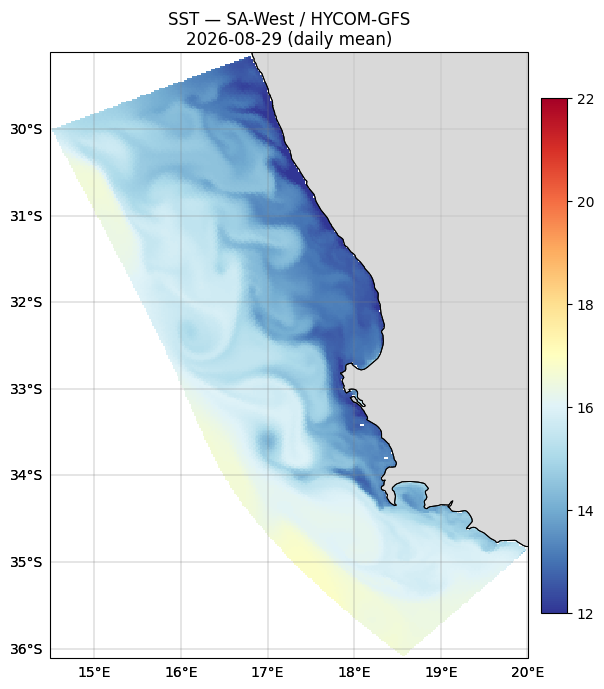

In [11]:

ds_west = xr.open_dataset(filepath("SA-West", "HYCOM-GFS"))
sst = ds_west.temp.isel(time=0, depth=0)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
im = plot_field(ax, sst, vmin=12, vmax=22)
ax.set_title(
    f"SST — SA-West / HYCOM-GFS\n{pd.Timestamp(sst.time.values).date()} (daily mean)"
)
plt.colorbar(im, ax=ax).remove()  # avoid duplicate colorbar from plot_field default
im2 = plot_field(ax, sst, vmin=12, vmax=22, add_colorbar=False)
fig.tight_layout()


You can clearly see the signature of the Benguela upwelling system —
cold water hugging the coast where equatorward, upwelling-favourable winds
pull cold, deep water to the surface.


## 5. Comparing the four forecast configurations

This is the heart of an operational-oceanography exercise: for the *same*
region and the *same* day, how much does the forecast change depending on
which global ocean model supplies the boundary conditions (HYCOM vs.
Mercator) and which atmospheric product forces the surface (GFS vs. SAWS)?

We'll load SST for all four SA-West configurations on the first forecast day
and plot them side by side on a common colour scale.


/var/folders/xx/yfv8g48909qbhg0jw1wqbph80000gt/T/ipykernel_69316/2308925587.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.06, 1, 0.96])


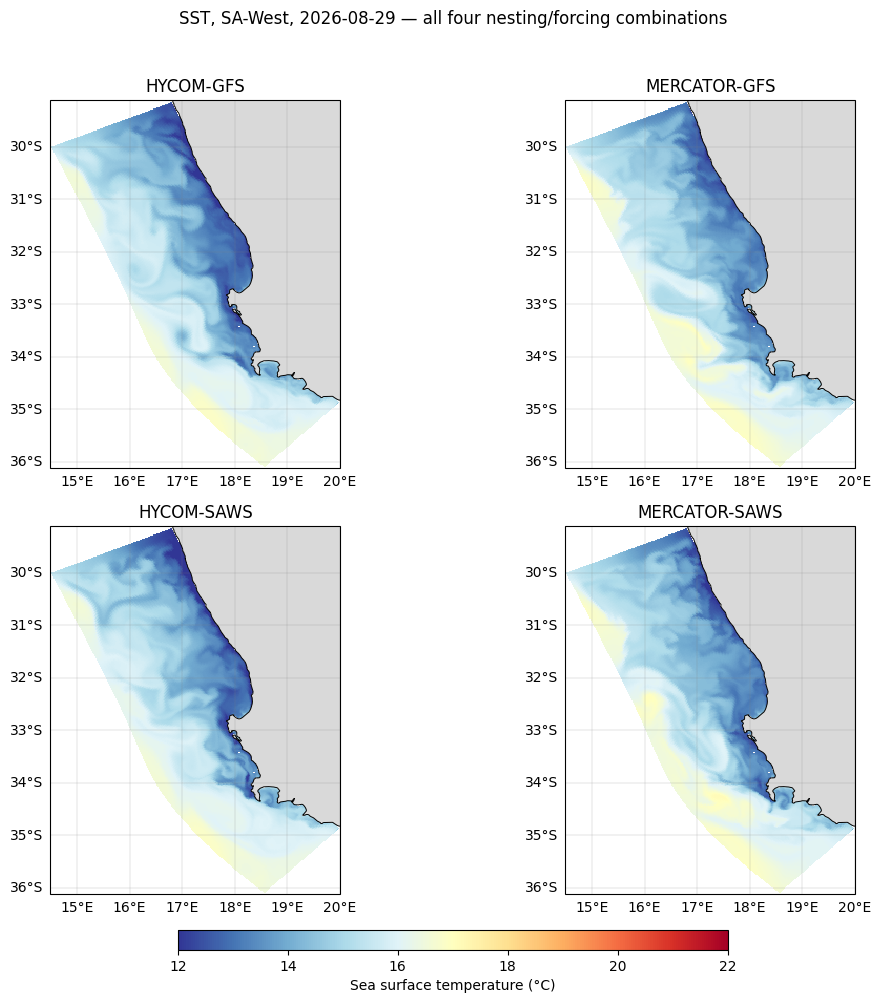

In [12]:

sst_by_config = {}
for config in CONFIGS:
    ds_c = xr.open_dataset(filepath("SA-West", config))
    sst_by_config[config] = ds_c.temp.isel(time=0, depth=0).load()

vmin, vmax = 12, 22
fig, axes = plt.subplots(
    2, 2, figsize=(11, 10), subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, config in zip(axes.flat, CONFIGS):
    im = plot_field(ax, sst_by_config[config], vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(config)

fig.suptitle(
    f"SST, SA-West, {pd.Timestamp(sst_by_config[CONFIGS[0]].time.values).date()} "
    "— all four nesting/forcing combinations",
    y=0.98,
)
cax = fig.add_axes([0.25, 0.04, 0.5, 0.02])
fig.colorbar(im, cax=cax, orientation="horizontal", label="Sea surface temperature (°C)")
fig.tight_layout(rect=[0, 0.06, 1, 0.96])


### Isolating the effect of the ocean nesting model vs. the atmospheric forcing

We can separate the two sources of forecast spread by taking differences:

- **HYCOM-GFS − MERCATOR-GFS**: same atmospheric forcing, different ocean
  boundary conditions → isolates the effect of the **nesting/boundary
  model**.
- **HYCOM-GFS − HYCOM-SAWS**: same ocean boundary conditions, different
  atmospheric forcing → isolates the effect of the **atmospheric forcing**.


/var/folders/xx/yfv8g48909qbhg0jw1wqbph80000gt/T/ipykernel_69316/3901332355.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 1])


RMS difference from ocean nesting choice:      0.507 degC
RMS difference from atmospheric forcing choice: 0.380 degC


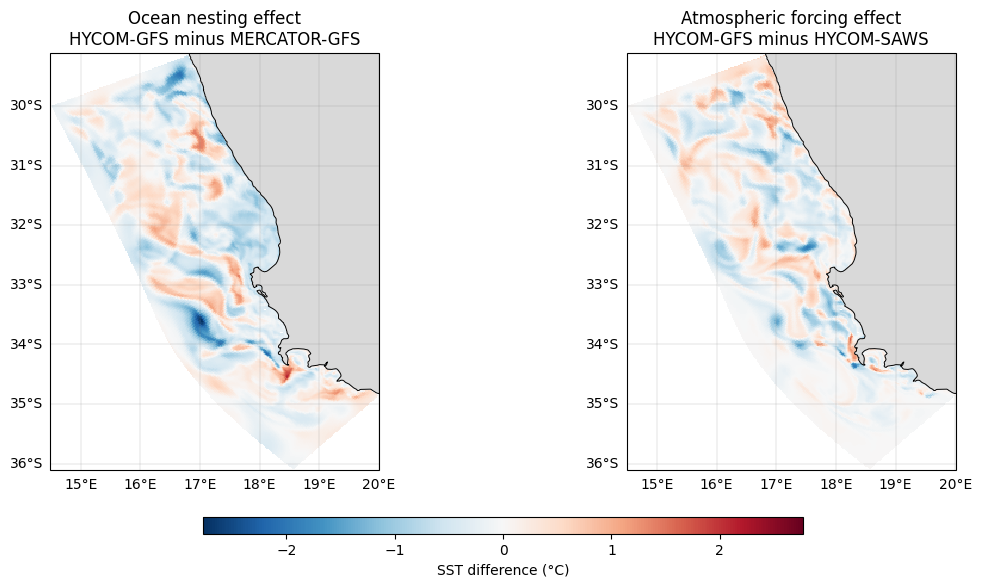

In [13]:

diff_ocean = sst_by_config["HYCOM-GFS"] - sst_by_config["MERCATOR-GFS"]
diff_atmos = sst_by_config["HYCOM-GFS"] - sst_by_config["HYCOM-SAWS"]

dmax = float(np.nanmax(np.abs([diff_ocean, diff_atmos])))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})
im0 = plot_field(axes[0], diff_ocean, cmap="RdBu_r", vmin=-dmax, vmax=dmax, add_colorbar=False)
axes[0].set_title("Ocean nesting effect\nHYCOM-GFS minus MERCATOR-GFS")
im1 = plot_field(axes[1], diff_atmos, cmap="RdBu_r", vmin=-dmax, vmax=dmax, add_colorbar=False)
axes[1].set_title("Atmospheric forcing effect\nHYCOM-GFS minus HYCOM-SAWS")

cax = fig.add_axes([0.25, 0.02, 0.5, 0.03])
fig.colorbar(im1, cax=cax, orientation="horizontal", label="SST difference (°C)")
fig.tight_layout(rect=[0, 0.07, 1, 1])

print(f"RMS difference from ocean nesting choice:      {float(np.sqrt(np.nanmean(diff_ocean**2))):.3f} degC")
print(f"RMS difference from atmospheric forcing choice: {float(np.sqrt(np.nanmean(diff_atmos**2))):.3f} degC")


On this forecast day, compare the RMS values printed above and the
spatial pattern of each difference map — is the SST forecast here more
sensitive to the choice of boundary/nesting model, or to the choice of
atmospheric forcing? (Try re-running this cell for a *later* forecast day,
by changing `time=0` to a larger index above — does the answer change as the
forecast lead time grows? This is exactly the kind of question an operational
forecaster asks when deciding which configuration to trust, or whether to
treat the four runs as a simple 4-member ensemble.)


## 6. Vertical structure

The tier-3 files give us a handful of fixed depth levels, which is enough to
look at how temperature and salinity vary with depth, and how consistent
that structure is across the four configurations.


Profile location: -32.60 N, 18.90 E


/var/folders/xx/yfv8g48909qbhg0jw1wqbph80000gt/T/ipykernel_69316/3163481630.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lat_idx = ds_west.dims["latitude"] // 2
/var/folders/xx/yfv8g48909qbhg0jw1wqbph80000gt/T/ipykernel_69316/3163481630.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  lon_idx = int(ds_west.dims["longitude"] * 0.8)


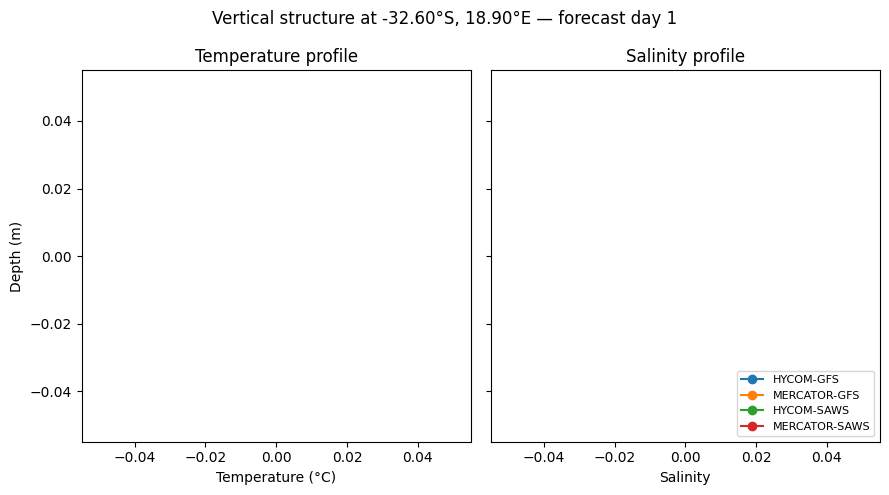

In [14]:

# pick an offshore point, away from the coast and its NaNs
lat_idx = ds_west.dims["latitude"] // 2
lon_idx = int(ds_west.dims["longitude"] * 0.8)
lat_pt = float(ds_west.latitude[lat_idx])
lon_pt = float(ds_west.longitude[lon_idx])
print(f"Profile location: {lat_pt:.2f} N, {lon_pt:.2f} E")

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
for config in CONFIGS:
    ds_c = xr.open_dataset(filepath("SA-West", config))
    temp_profile = ds_c.temp.isel(time=0, latitude=lat_idx, longitude=lon_idx).load()
    salt_profile = ds_c.salt.isel(time=0, latitude=lat_idx, longitude=lon_idx).load()
    axes[0].plot(temp_profile, temp_profile.depth, "o-", label=config)
    axes[1].plot(salt_profile, salt_profile.depth, "o-", label=config)

axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth (m)")
axes[1].set_xlabel("Salinity")
axes[0].set_title("Temperature profile")
axes[1].set_title("Salinity profile")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Vertical structure at {lat_pt:.2f}°S, {lon_pt:.2f}°E — forecast day 1")
fig.tight_layout()


Note that the fixed z-levels used here (0, 5, 10, 50, 100, 500, 1000 m)
are coarse compared to CROCO's native sigma layers — fine for a broad look at
stratification, but for detailed mixed-layer work you would want the
higher-resolution native output instead.


## 7. Forecast evolution over the lead time

An operational forecast isn't just a single snapshot — it's a trajectory into
the future, and its skill typically degrades with increasing lead time. Let's
track SST at our profile location over the whole forecast window for all four
configurations.

One practical detail: the GFS-forced runs provide a 10-day forecast while the
SAWS-forced runs only extend to about 8 days (SAWS produces relatively
short-range regional forecasts, compared to the longer-range global GFS) — a
good reminder that in an operational system, the length of your ocean
forecast is often limited by the length of the atmospheric forecast driving
it. We'll plot each series over its own full length, so this limitation is
visible directly in the plot.


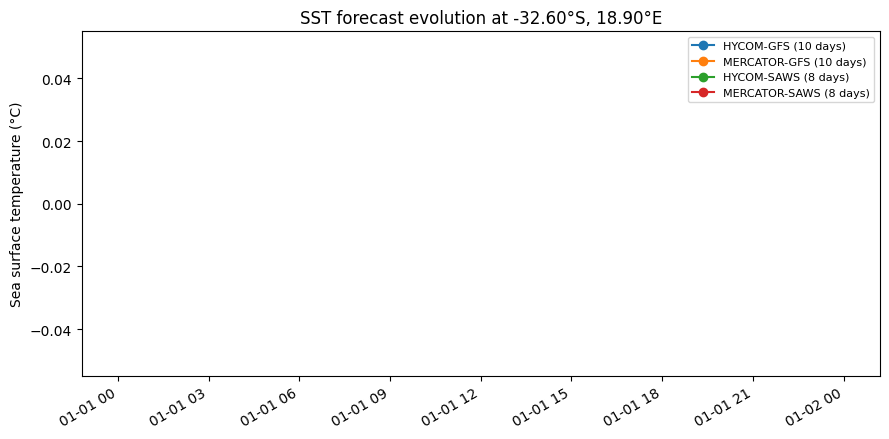

In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))
for config in CONFIGS:
    ds_c = xr.open_dataset(filepath("SA-West", config))
    sst_ts = ds_c.temp.isel(depth=0, latitude=lat_idx, longitude=lon_idx).load()
    ax.plot(sst_ts.time, sst_ts, "o-", label=f"{config} ({sst_ts.sizes['time']} days)")

ax.set_ylabel("Sea surface temperature (°C)")
ax.set_title(f"SST forecast evolution at {lat_pt:.2f}°S, {lon_pt:.2f}°E")
ax.legend(fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()


The spread between the four lines at a given date is a simple,
poor-man's estimate of forecast uncertainty at that lead time — with only
four members and no formal perturbation strategy this is *not* a real
ensemble forecast, but the same principle (running multiple
configurations/forcings and looking at their spread) underlies genuine
ensemble ocean forecasting systems.


## 8. Surface currents

So far we've looked at scalar fields (temperature, salinity). Let's compute
current speed from the baroclinic velocity components and visualise both
speed and direction.


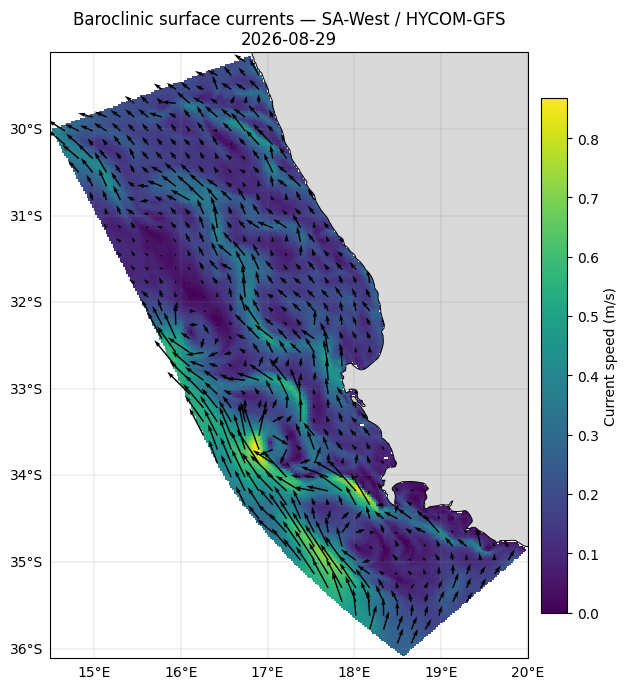

In [16]:

u = ds_west.u.isel(time=0, depth=0)
v = ds_west.v.isel(time=0, depth=0)
speed = np.sqrt(u**2 + v**2)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
im = plot_field(ax, speed, cmap="viridis", vmin=0, add_colorbar=False)
plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02, label="Current speed (m/s)")

# subsample the vectors so the quiver plot is readable
step = 8
ax.quiver(
    u.longitude[::step], u.latitude[::step],
    u.values[::step, ::step], v.values[::step, ::step],
    transform=ccrs.PlateCarree(), scale=8, width=0.003, color="k",
)
ax.set_title(
    f"Baroclinic surface currents — SA-West / HYCOM-GFS\n{pd.Timestamp(u.time.values).date()}"
)
fig.tight_layout()


## 9. Bottom temperature

The `*_bottom` variables sample the model's bottom-most sigma layer rather
than a fixed z-level, so they follow the seabed even in shallow coastal
water where the 0/5/10 m z-levels above might already be below the bottom.
This is often the field of interest for e.g. rock lobster or demersal fish
habitat studies.


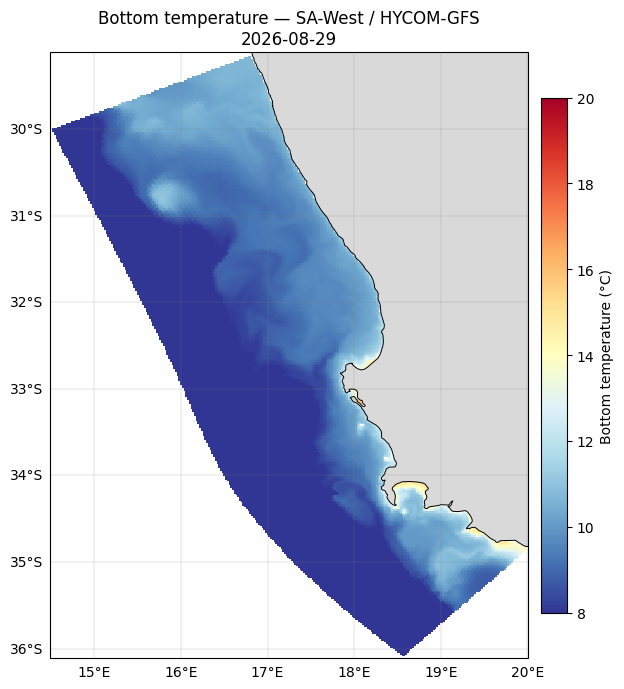

In [17]:

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
im = plot_field(ax, ds_west.temp_bottom.isel(time=0), vmin=8, vmax=20, add_colorbar=False)
plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02, label="Bottom temperature (°C)")
ax.set_title(
    f"Bottom temperature — SA-West / HYCOM-GFS\n{pd.Timestamp(ds_west.time.isel(time=0).values).date()}"
)
fig.tight_layout()


Compare this to the SST map in Section 4 — the cold band near the coast
in the SST map (upwelled surface water) versus the bottom temperature here
tells you something about how deep/coastal-trapped the upwelling signal is.


## 10. The two regions side by side

Finally, a quick look at how the two forecast domains relate to each other in
space — SA-West covering the Benguela shelf, SA-East a smaller, higher
priority domain around Cape Point/False Bay.


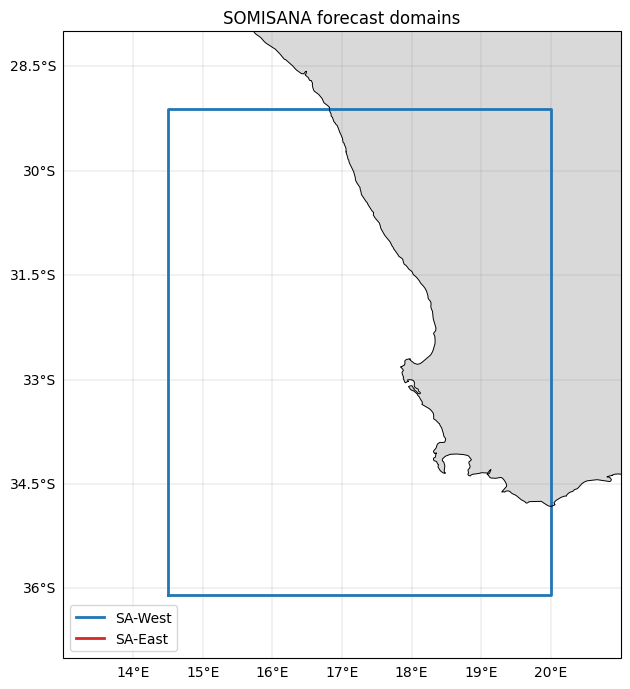

In [18]:

ds_east = xr.open_dataset(filepath("SA-East", "HYCOM-GFS"))

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
ax.coastlines(resolution="10m", linewidth=0.7, zorder=3)
ax.set_extent([13, 21, -37, -28], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.5", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

def domain_box(ds, **kwargs):
    lon_min, lon_max = float(ds.longitude.min()), float(ds.longitude.max())
    lat_min, lat_max = float(ds.latitude.min()), float(ds.latitude.max())
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        transform=ccrs.PlateCarree(), **kwargs,
    )

domain_box(ds_west, color="C0", lw=2, label="SA-West")
domain_box(ds_east, color="C3", lw=2, label="SA-East")
ax.legend(loc="lower left")
ax.set_title("SOMISANA forecast domains")
fig.tight_layout()


## Summary and suggested exercises

You've now explored the structure, metadata, and content of SOMISANA's
operational CROCO forecasts, and used the four HYCOM/MERCATOR × GFS/SAWS
configurations to get a feel for how sensitive a short-range ocean forecast
is to its boundary and atmospheric forcing.

Some ideas to extend this notebook:

1. **Anomalies**: compute the difference between each configuration and the
   4-configuration ensemble mean, for every forecast day — does spread grow
   with lead time?
2. **Time–depth sections**: pick a point and plot a Hovmöller diagram of
   temperature vs. depth vs. forecast day, to see how the mixed layer evolves.
3. **A transect**: extract a cross-shelf section (fixed latitude, varying
   longitude and depth) to look at the upwelling front in cross-section.
4. **Compare `u`/`v` totals**: SOMISANA's other tiers of output also include
   the barotropic component — see if you can find and add it to get the total
   current.
5. **Fetch a fresh forecast**: the files here are a single snapshot from
   https://catalog.somisana.ac.za/catalog/. Try downloading tomorrow's cycle
   and comparing it to today's — do the two forecasts agree on the days they
   have in common? (This is called forecast *consistency*, a standard
   operational-forecasting diagnostic.)
